# Analyse and plot the different projections

Note that we computed and show here all GCMs and scenarios that are currently available at the OGGM cluster. However, you have to choose those scenarios that are suitable and representative for your study. [For example, you could select them after the method of Hausfather et al., 2022)](https://www.nature.com/articles/d41586-022-01192-2) or [aggregate them after their warming levels (e.g. as in Rounce et al., 2023)](https://doi.org/10.1126/science.abo1324).

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (14, 8)

# controls what is stored INSIDE the notebook (the "inline" view)
# keeping this low keeps the .ipynb file size small, and makes it easier to load/view
%config InlineBackend.figure_format = 'jpg' # JPG is much smaller than PNG
plt.rcParams['figure.dpi'] = 75 

In [2]:
# change this path to your local path 
path = '/home/www/oggm/oggm-standard-projections/oggm-standard-projections-csv-files/'
path = path + '1.6.3/w5e5/per_glacier_spinup/'

In [3]:
# IPCC colors from: https://pyam-iamc.readthedocs.io/en/stable/tutorials/ipcc_colors.html
colors_scenario = {# AR6 ssps (from CMIP6)
                    'ssp119':'#00a9cf', 'ssp126': '#003466',
                   'ssp245':'#f69320', 'ssp370':'#df0000',
                   'ssp434':'#2274ae',
                  'ssp460': '#b0724e', 'ssp534-over':'#92397a',
                  'ssp585':'#980002',
                   # AR5 rcp colors
                  #'rcp26': '#0000FF', 'rcp45':'#79BCFF', 'rcp60':'#FF822D', 'rcp85':'#FF0000',
                  # AR6 rcp colors
                  'rcp26': '#003466', 'rcp45':'#709fcc', 'rcp60':'#c37900', 'rcp85':'#980002'}

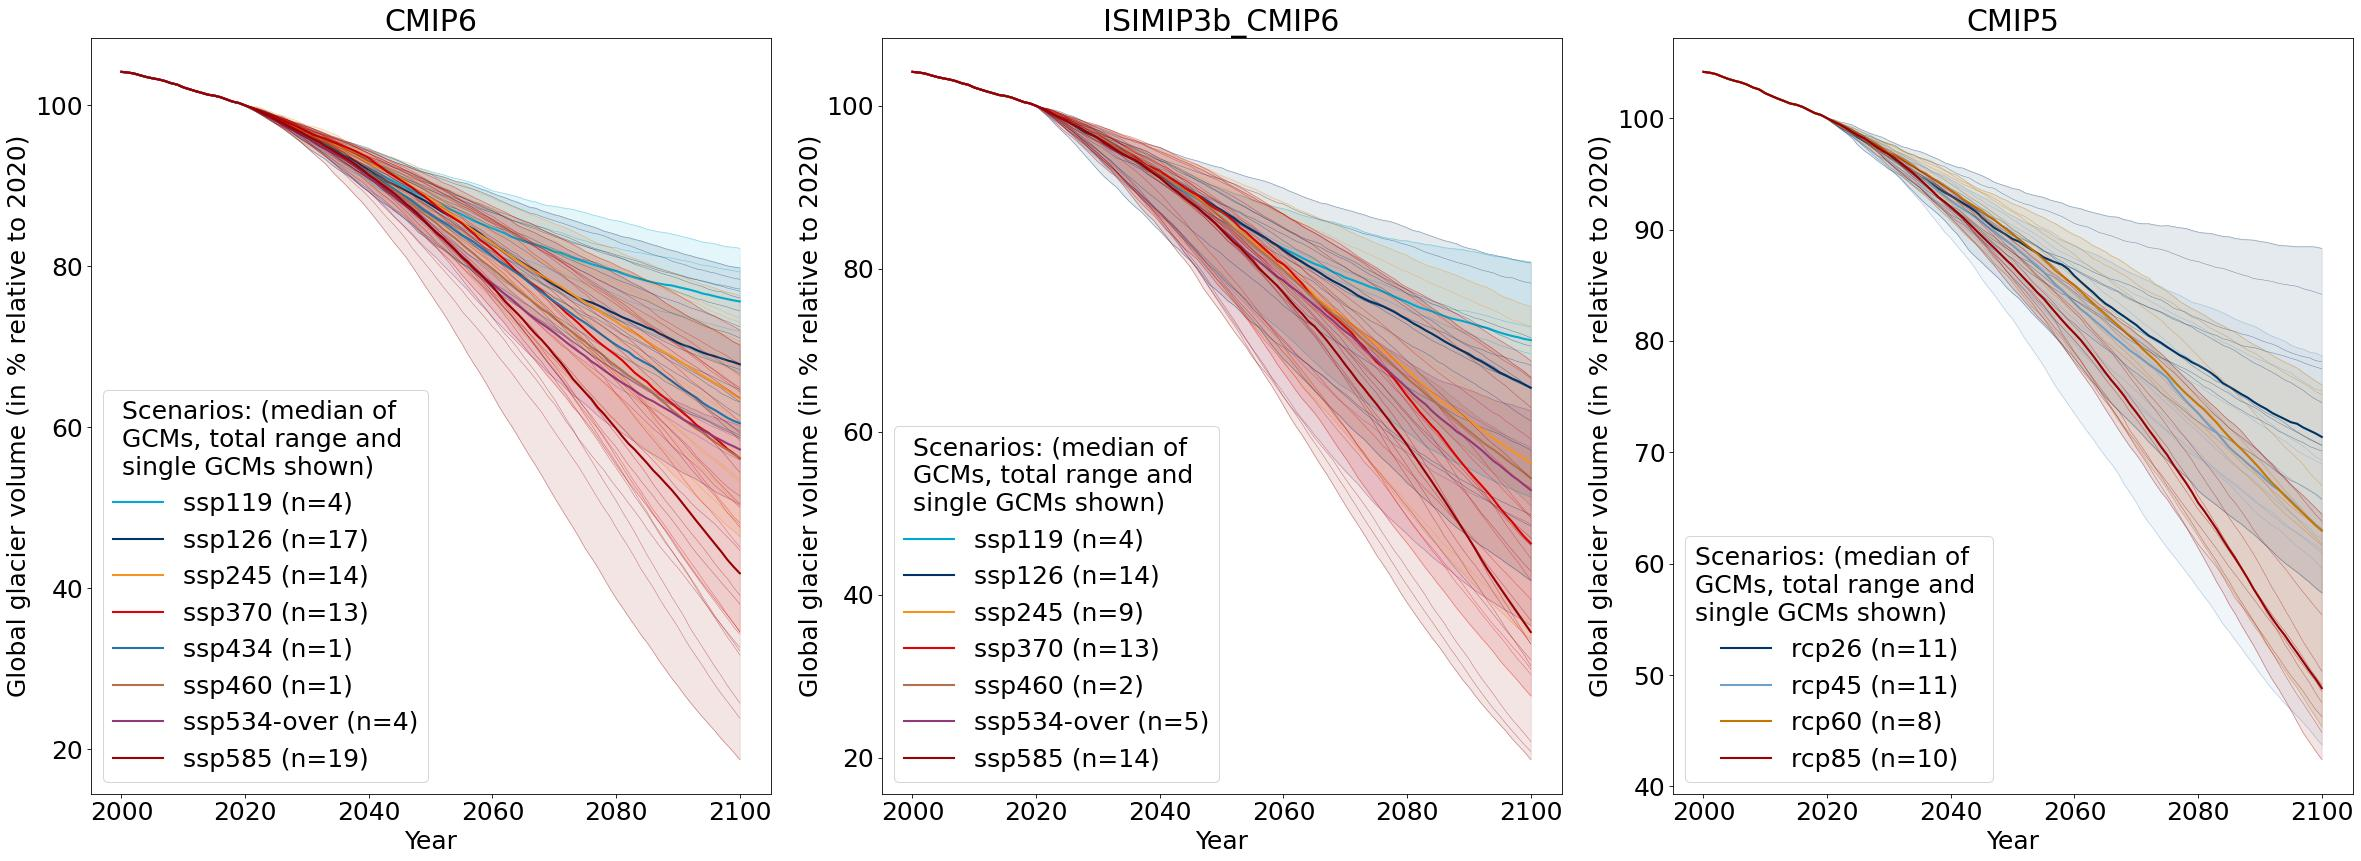

In [4]:
df_meta = pd.read_csv(f'{path}/common_running_2100/metadata.csv')
end_year= 2100
# let's remove the IITM-ESM ssp370, as it ends already end of 2098 (i.e. has end_year 2099)
df_meta = df_meta.loc[df_meta.end_year!=2099]
# we only show the projections until beginning of 2100, so we are interested in all gcms
# with either end_year 2100 or 2101
df_meta.loc[df_meta.end_year==end_year+1,'end_year'] = end_year

plt.rc('font', size=24)

plt.figure(figsize=(32,12)) #harey=True, sharex=True)
for j,cmip in enumerate(['CMIP6', 'ISIMIP3b_CMIP6', 'CMIP5']):
    plt.subplot(1,3,j+1)
    ax = plt.gca()
    scenario_list = list(df_meta.loc[(df_meta.cmip==cmip) & (df_meta.end_year==end_year)].scenario.unique())
    scenario_list.sort()
    for scenario in scenario_list:
        idir = path + 'common_running_2100/' + f'volume/{cmip}/{end_year}/global/'

        df = pd.read_csv(idir + f'{scenario}.csv', index_col=0)
        df_rel = 100*df/df.loc[2020]

        ax.plot(df.index, df_rel.median(axis=1), lw=2, color=colors_scenario[scenario], label = f'{scenario} (n={len(df_rel.columns)})')
        ax.plot(df.index, df_rel, lw=0.5, alpha = 0.5, color=colors_scenario[scenario]);
        ax.fill_between(df.index, df_rel.min(axis=1), df_rel.max(axis=1), alpha=0.1, color=colors_scenario[scenario])
        
        #if j==0:
        ax.set_ylabel('Global glacier volume (in % relative to 2020)')
        #else:
        #    ax.set_ylabel('')
        ax.set_xlabel('Year')
    ax.set_title(cmip)
    plt.legend(title='Scenarios: (median of \nGCMs, total range and \nsingle GCMs shown)');
    plt.tight_layout()
    plt.savefig('global_glacier_volume_until2100_common_running_2100.png')

### Figure 2: until 2300

In [5]:

df_meta = pd.read_csv(f'{path}/common_running_2100_2300/metadata.csv')
# we only show the projections until beginning of 2300, so we are interested in all gcms
# with either end_year 2300 or 2301
df_meta.loc[df_meta.end_year==end_year+1,'end_year'] = end_year
df_rel_2300 = pd.DataFrame(columns = df_meta.gcm.unique())

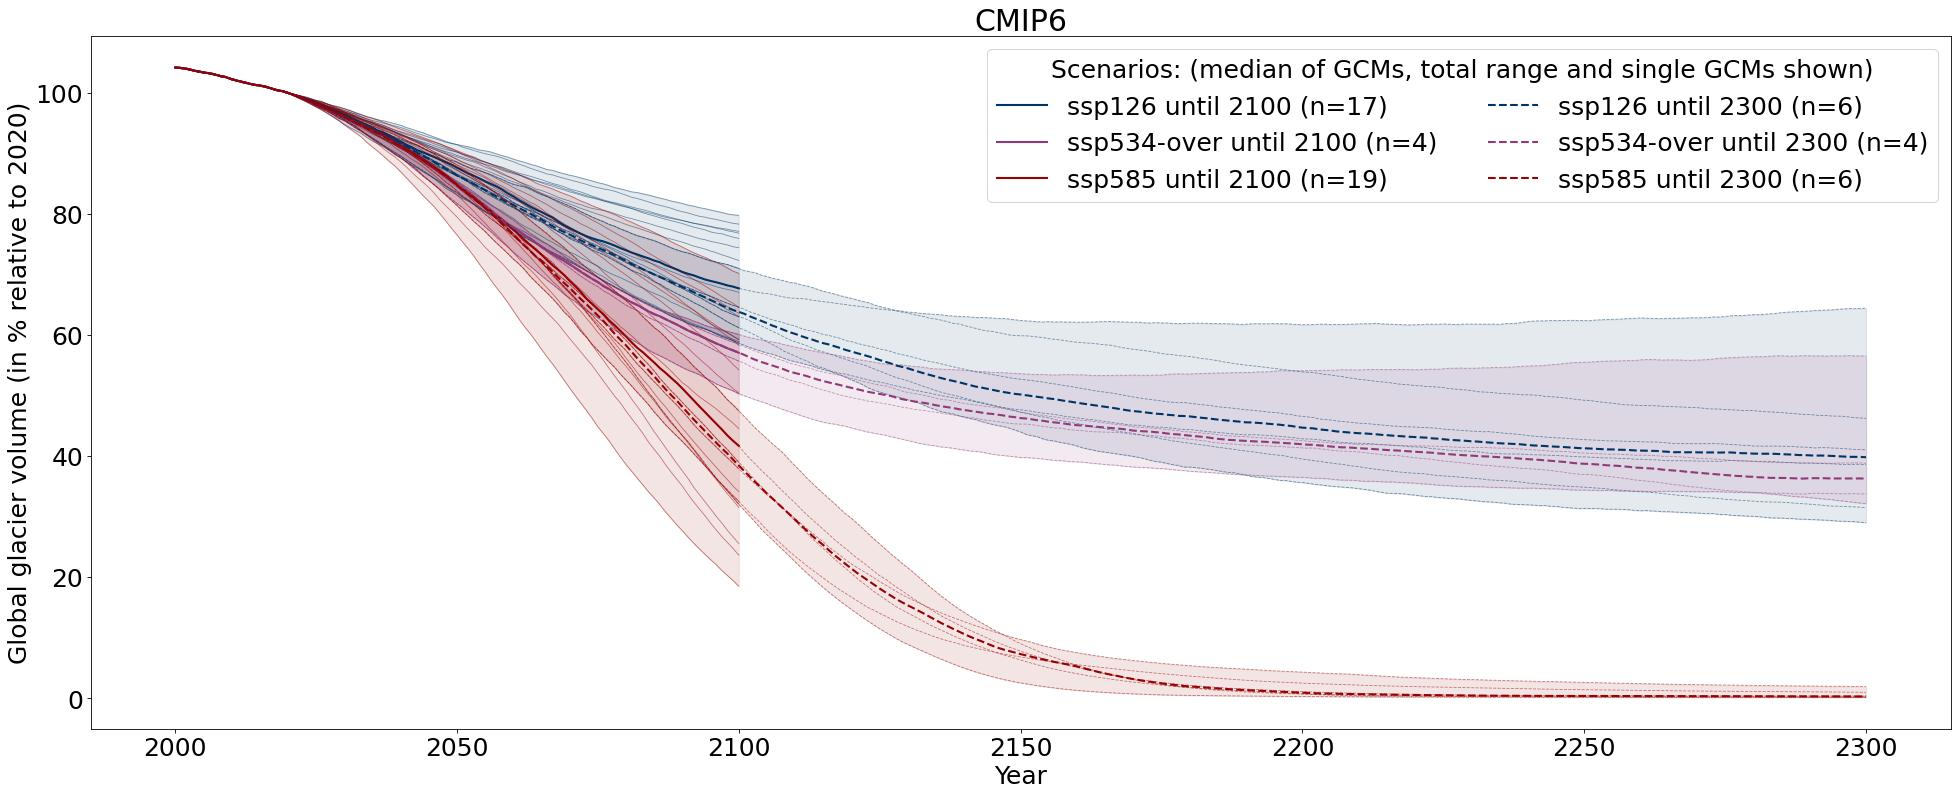

In [6]:
plt.rc('font', size=24)
end_year= 2100
ls_d = {2100:'-', 2300:'--'}
plt.figure(figsize=(32,12)) #harey=True, sharex=True)
for j,cmip in enumerate(['CMIP6']):
    ax = plt.gca()
    for end_year in [2100,2300]:
        ls = ls_d[end_year]
        # let's only plot those scenarios that exist only until 2300
        scenario_list = list(df_meta.loc[(df_meta.cmip==cmip) & (
            (df_meta.end_year==2300) | (df_meta.end_year==2301))].scenario.unique())
        scenario_list.sort()
        for scenario in scenario_list:
            idir = path + 'common_running_2100_2300/' + f'volume/{cmip}/{end_year}/global/'

            df = pd.read_csv(idir + f'{scenario}.csv', index_col=0)
            df_rel = 100*df/df.loc[2020]

            ax.plot(df.index, df_rel.median(axis=1), lw=2, color=colors_scenario[scenario],
                    label = f'{scenario} until {end_year} (n={len(df_rel.columns)})', ls= ls_d[end_year])
            ax.plot(df.index, df_rel, lw=0.8, alpha = 0.5, color=colors_scenario[scenario],
                   ls= ls_d[end_year]);
            ax.fill_between(df.index, df_rel.min(axis=1), df_rel.max(axis=1), alpha=0.1, color=colors_scenario[scenario])

            ax.set_ylabel('Global glacier volume (in % relative to 2020)')
            ax.set_xlabel('Year')
            if end_year == 2300:
                df_rel_2300.loc[f'{cmip}\n{scenario}:\nn={len(df_rel.columns)}', df_rel.columns] = df_rel.loc[2299]
        #if end_year == 2100:
    plt.legend(title='Scenarios: (median of GCMs, total range and single GCMs shown)', ncol=2);

    ax.set_title(cmip)
    plt.savefig('global_glacier_volume_until2300_common_running_2100_2300_cmip6.png')

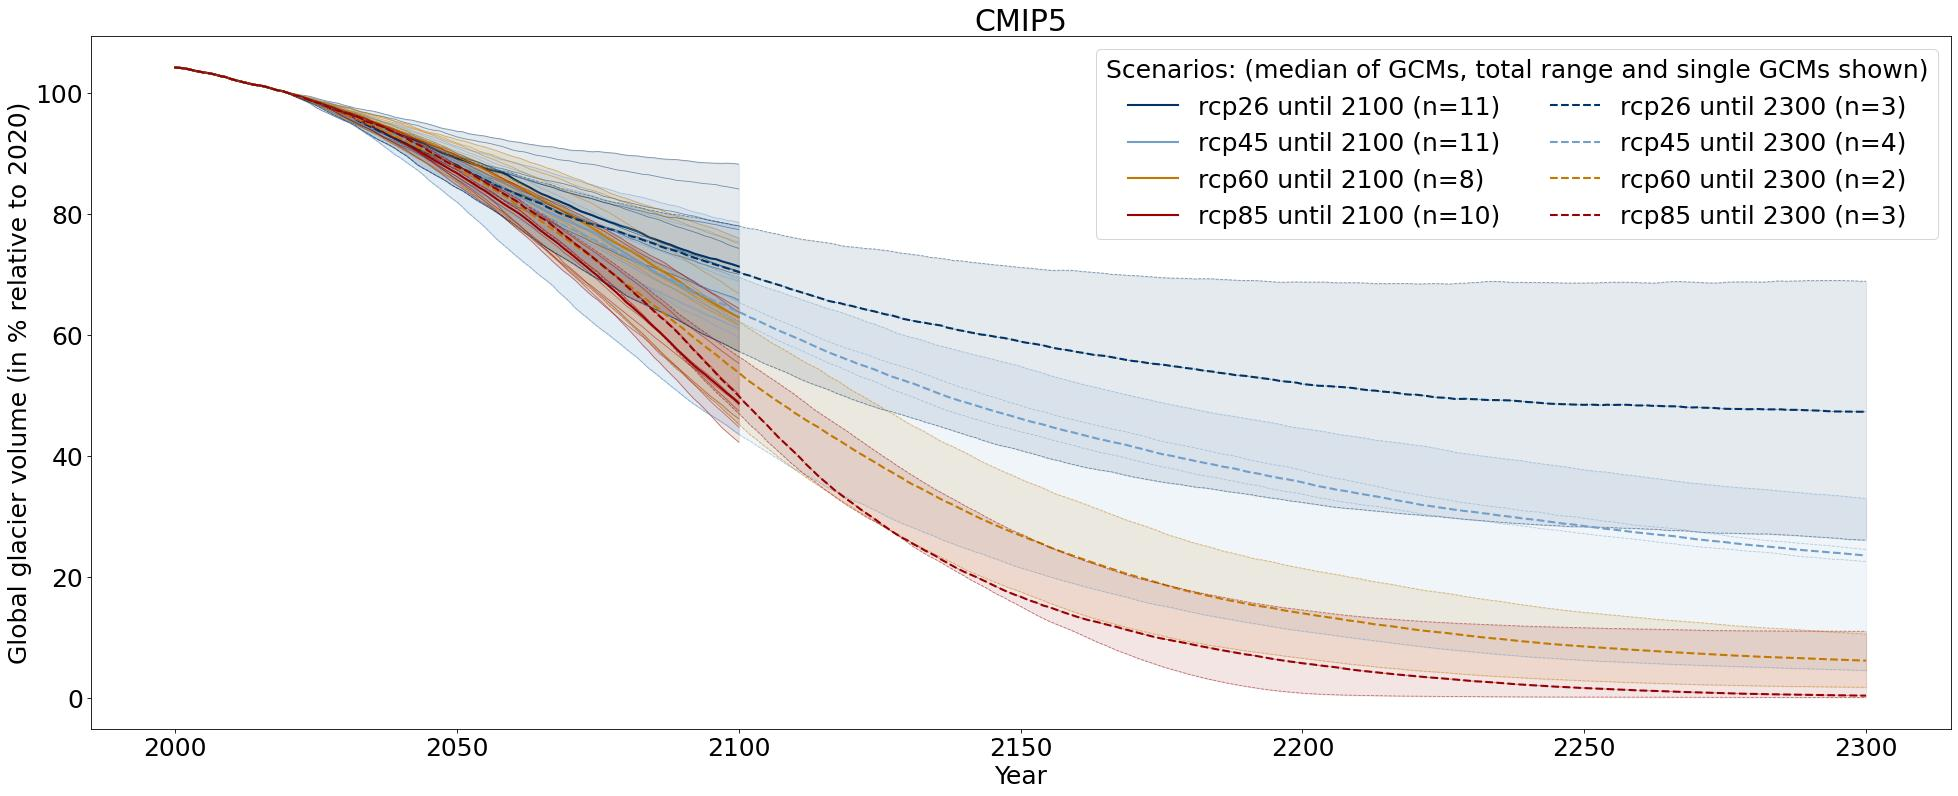

In [7]:

plt.rc('font', size=24)
end_year= 2100
ls_d = {2100:'-', 2300:'--'}
plt.figure(figsize=(32,12)) #harey=True, sharex=True)
for j,cmip in enumerate(['CMIP5']):
    ax = plt.gca()
    for end_year in [2100,2300]:
        ls = ls_d[end_year]
        # let's only plot those scenarios that exist only until 2300
        scenario_list = list(df_meta.loc[(df_meta.cmip==cmip) & (
            (df_meta.end_year==2300) | (df_meta.end_year==2301))].scenario.unique())
        scenario_list.sort()
        for scenario in scenario_list:
            idir = path + 'common_running_2100_2300/' + f'volume/{cmip}/{end_year}/global/'

            df = pd.read_csv(idir + f'{scenario}.csv', index_col=0)
            df_rel = 100*df/df.loc[2020]

            ax.plot(df.index, df_rel.median(axis=1), lw=2, color=colors_scenario[scenario],
                    label = f'{scenario} until {end_year} (n={len(df_rel.columns)})', ls= ls_d[end_year])
            ax.plot(df.index, df_rel, lw=0.8, alpha = 0.5, color=colors_scenario[scenario],
                   ls= ls_d[end_year]);
            ax.fill_between(df.index, df_rel.min(axis=1), df_rel.max(axis=1), alpha=0.1, color=colors_scenario[scenario])

            ax.set_ylabel('Global glacier volume (in % relative to 2020)')
            ax.set_xlabel('Year')
            if end_year == 2300:
                df_rel_2300.loc[f'{cmip}\n{scenario}:\nn={len(df_rel.columns)}', df_rel.columns] = df_rel.loc[2299]
        #if end_year == 2100:
    plt.legend(title='Scenarios: (median of GCMs, total range and single GCMs shown)', ncol=2);

    ax.set_title(cmip)
    plt.savefig('global_glacier_volume_until2300_common_running_2100_2300_cmip5.png')

/tmp/ipykernel_467366/3318259842.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(df_rel_2300.dropna(how='all', axis=1).T, color='grey',


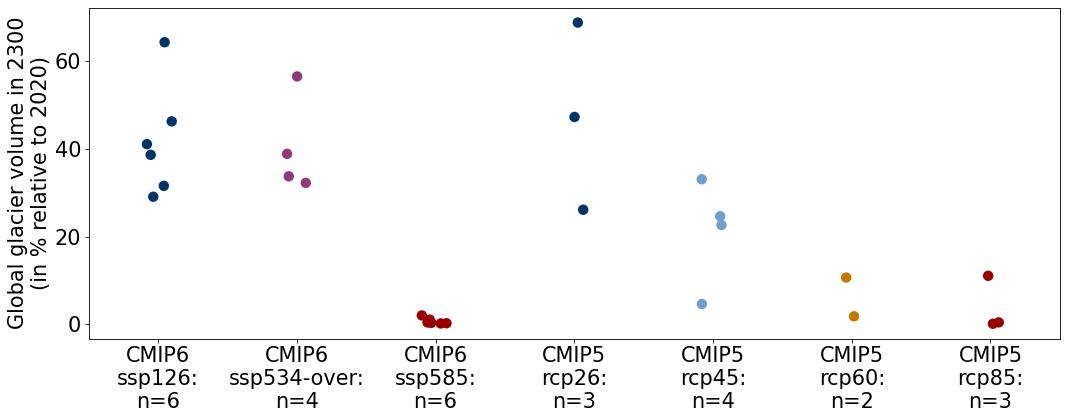

In [8]:
import seaborn as sns
colors_s = []
for s in df_rel_2300.index:
    colors_s.append(colors_scenario[s[6:-5]])

plt.figure(figsize=(14,6))
plt.rc('font', size=20)

#sns.boxplot(df_rel_2300.dropna(how='all', axis=1).T, saturation = 0.1,
#            color='grey', whis=0,fliersize=0)
sns.stripplot(df_rel_2300.dropna(how='all', axis=1).T, color='grey',
              palette = colors_s,
              alpha = 1, size=10)

plt.tight_layout()
plt.ylabel('Global glacier volume in 2300\n(in % relative to 2020)');

## Regional plots

In [9]:
d_reg_num_name = {}
d_reg_num_name['01'] = 'Alaska'
d_reg_num_name['02'] = 'Western Canada & USA'
d_reg_num_name['03'] = 'Arctic Canada North'
d_reg_num_name['04'] = 'Arctic Canada South'
d_reg_num_name['05'] = 'Greenland'
d_reg_num_name['06'] = 'Iceland'
d_reg_num_name['07'] = 'Svalbard and Jan Mayen'
d_reg_num_name['08'] = 'Scandinavia'
d_reg_num_name['09'] = 'Russian Arctic'
d_reg_num_name['10'] = 'North Asia'
d_reg_num_name['11'] = 'Central Europe'
d_reg_num_name['12'] = 'Caucasus and Middle East'
d_reg_num_name['13'] = 'Central Asia'
d_reg_num_name['14'] = 'South Asia West'
d_reg_num_name['15'] = 'South Asia East'
d_reg_num_name['16'] = 'Low Latitudes'
d_reg_num_name['17'] = 'Southern Andes'
d_reg_num_name['18'] = 'New Zealand'
d_reg_num_name['19'] = 'Antarctic and Subantarctic'

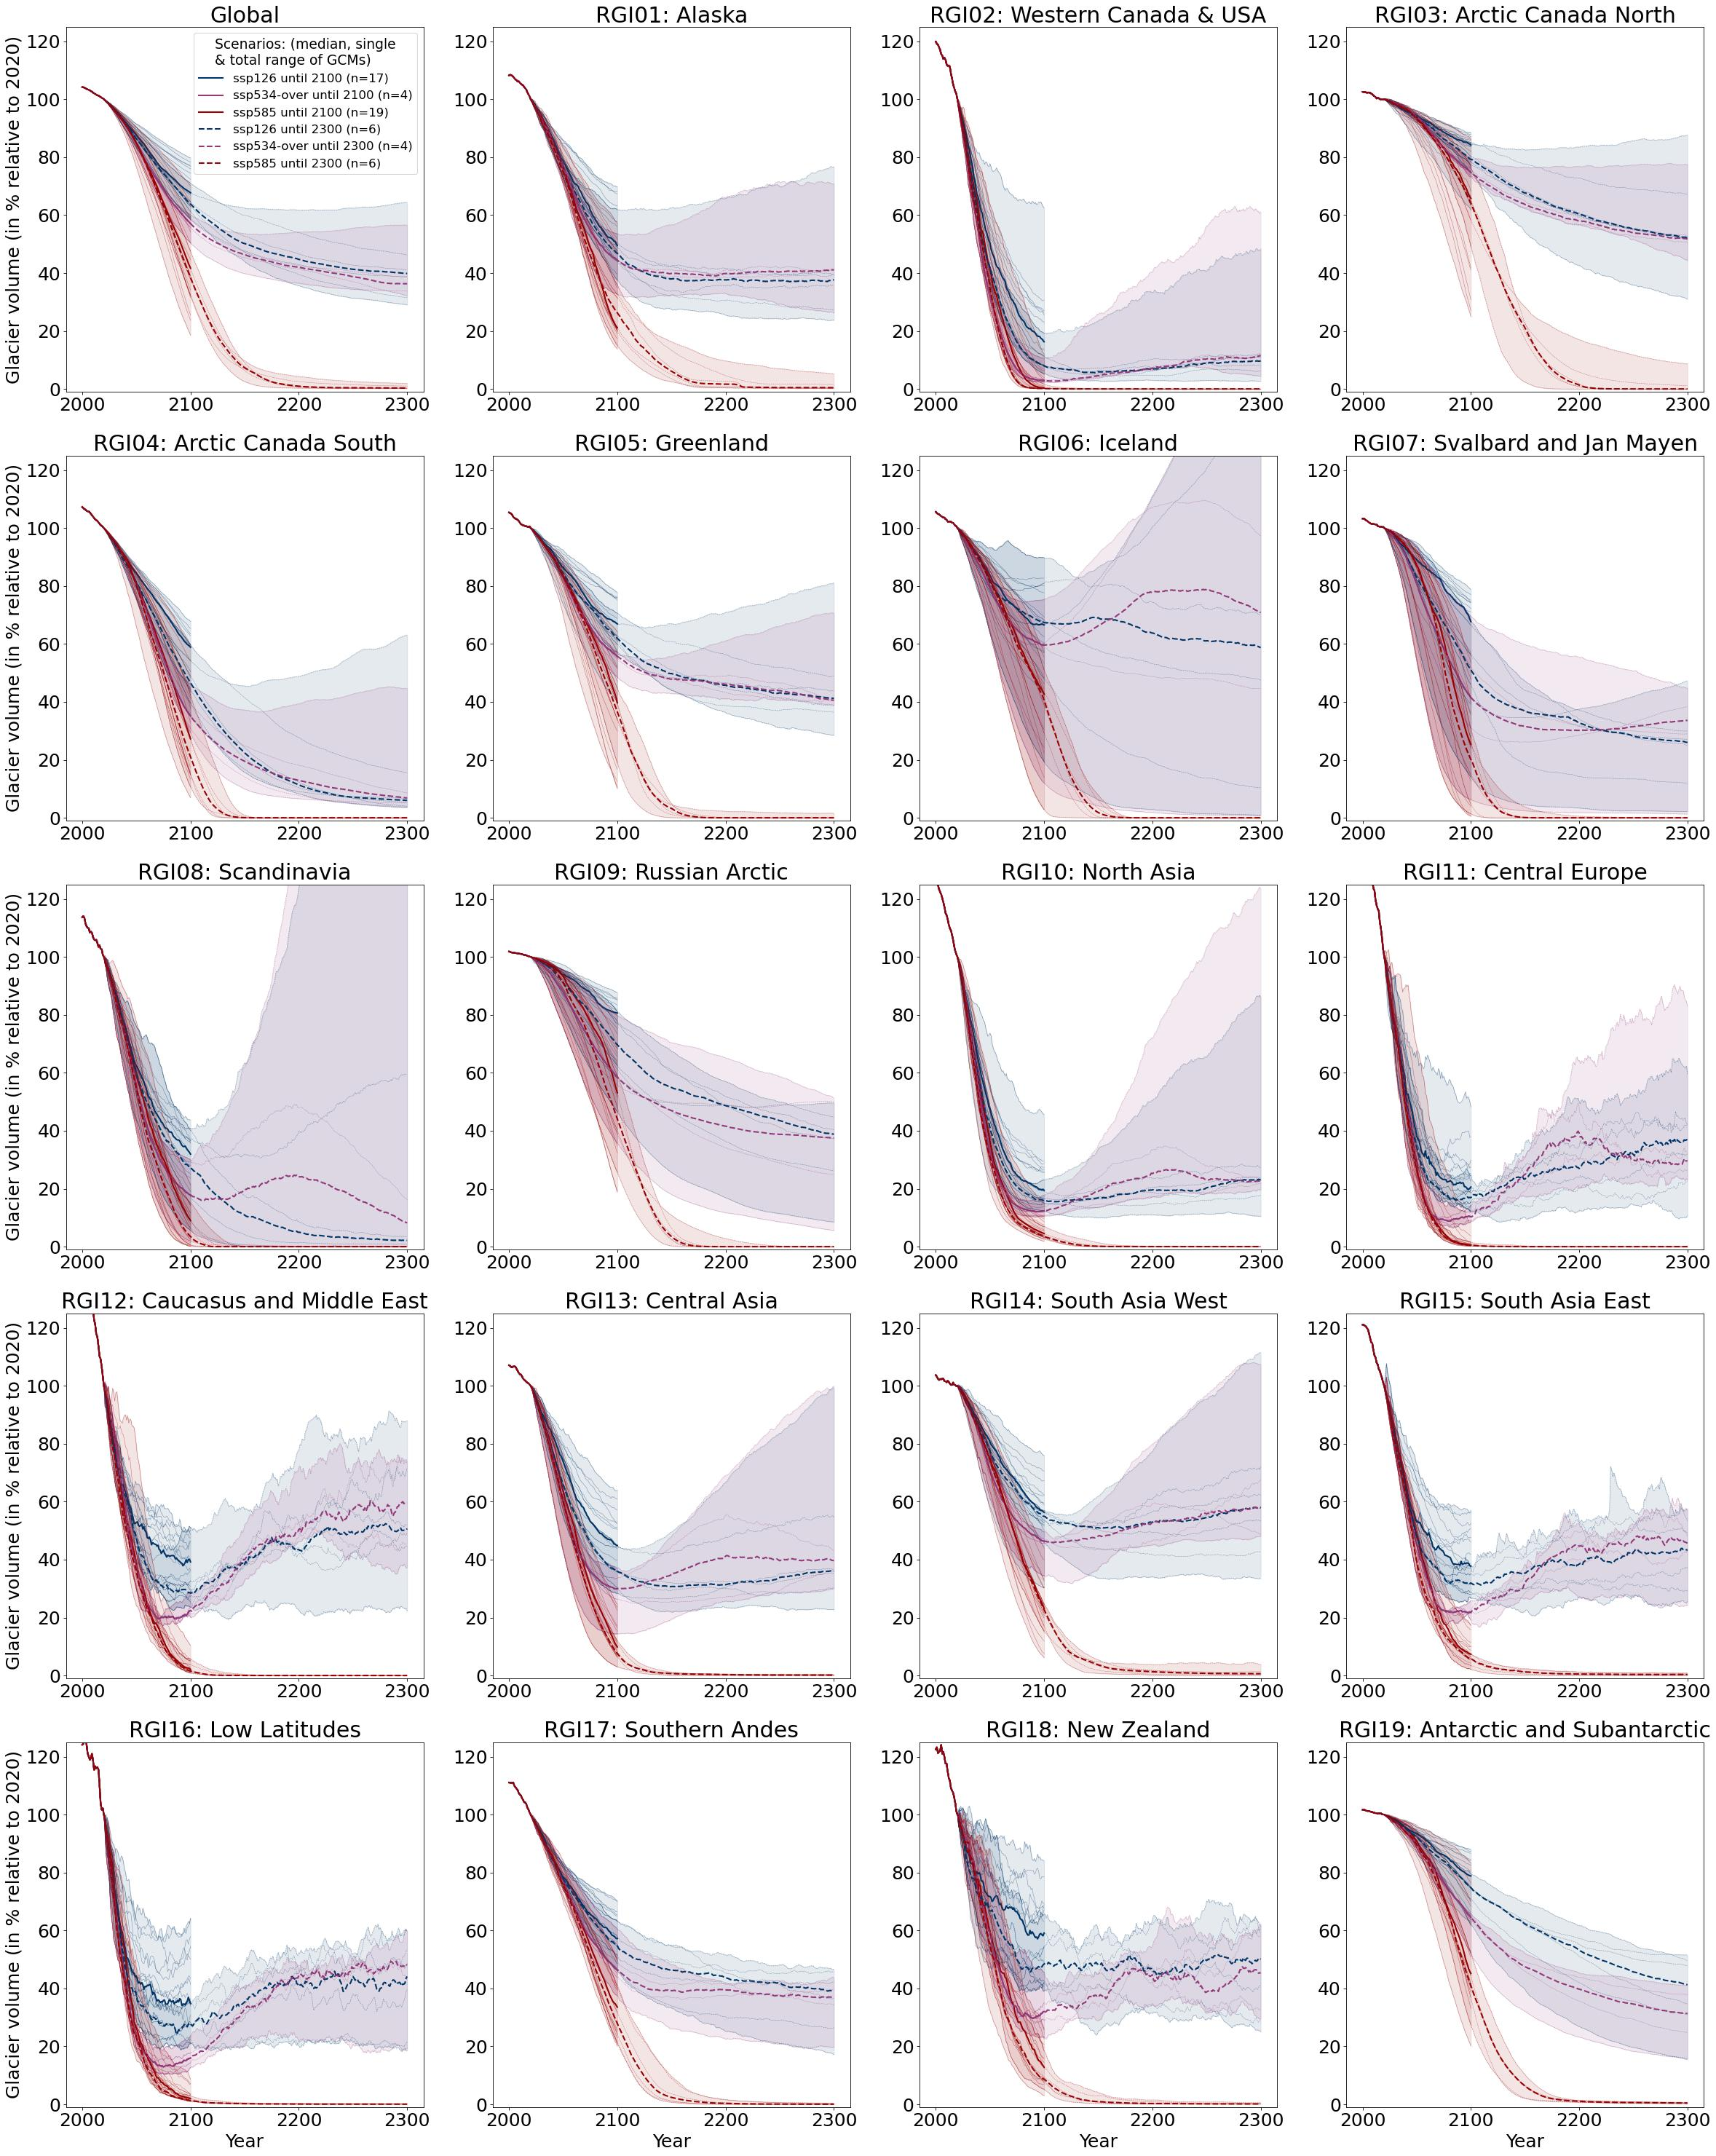

In [10]:
df_meta = pd.read_csv(f'{path}/common_running_2100_2300/metadata.csv')
end_year= 2100
ls_d = {2100:'-', 2300:'--'}
cmip = 'CMIP6'
plt.rc('font', size=24)
plt.figure(figsize=(32,40)) #harey=True, sharex=True)
#plt.ylabel('Volume (in % relative to 2020)')

for j,r in enumerate(['Global', 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]):
    plt.subplot(5,4,j+1)
    ax = plt.gca()

    if r == 'Global':
        rgi_reg = r
        rgi_reg_l = 'global'
        ax.set_title('Global')
    else:
        rgi_reg = f'{r:02}'
        rgi_reg_l = f'RGI{rgi_reg}'
        ax.set_title(f'{rgi_reg_l}: {d_reg_num_name[rgi_reg]}')
        
    for end_year in [2100,2300]:
        ls = ls_d[end_year]
        # let's only plot those scenarios that exist only until 2300
        scenario_list = list(df_meta.loc[(df_meta.cmip==cmip) & 
                             ((df_meta.end_year==2300)|(df_meta.end_year==2301))].scenario.unique())
        scenario_list.sort()
        for scenario in scenario_list:
            idir = path + 'common_running_2100_2300/' + f'volume/{cmip}/{end_year}/{rgi_reg_l}/'

            df = pd.read_csv(idir + f'{scenario}.csv', index_col=0)
            df_rel = 100*df/df.loc[2020]

            ax.plot(df.index, df_rel.median(axis=1), lw=2, color=colors_scenario[scenario],
                    label = f'{scenario} until {end_year} (n={len(df_rel.columns)})', ls= ls_d[end_year])
            ax.plot(df.index, df_rel, lw=0.5, alpha = 0.5, color=colors_scenario[scenario],
                   ls= ls_d[end_year]);
            ax.fill_between(df.index, df_rel.min(axis=1), df_rel.max(axis=1), alpha=0.1, color=colors_scenario[scenario])
    if j in [0,4,8,12,16]:
        ax.set_ylabel('Glacier volume (in % relative to 2020)')
    if j>=16:
        ax.set_xlabel('Year')
    if j == 0:
        ax.legend(title='Scenarios: (median, single\n& total range of GCMs)', ncol=1, fontsize=16, title_fontsize=18, loc = 'upper right');
    ax.set_ylim([-1,125])
plt.tight_layout()
plt.savefig('regional_glacier_volume_until2300_common_running_2100_2300_cmip6.png')

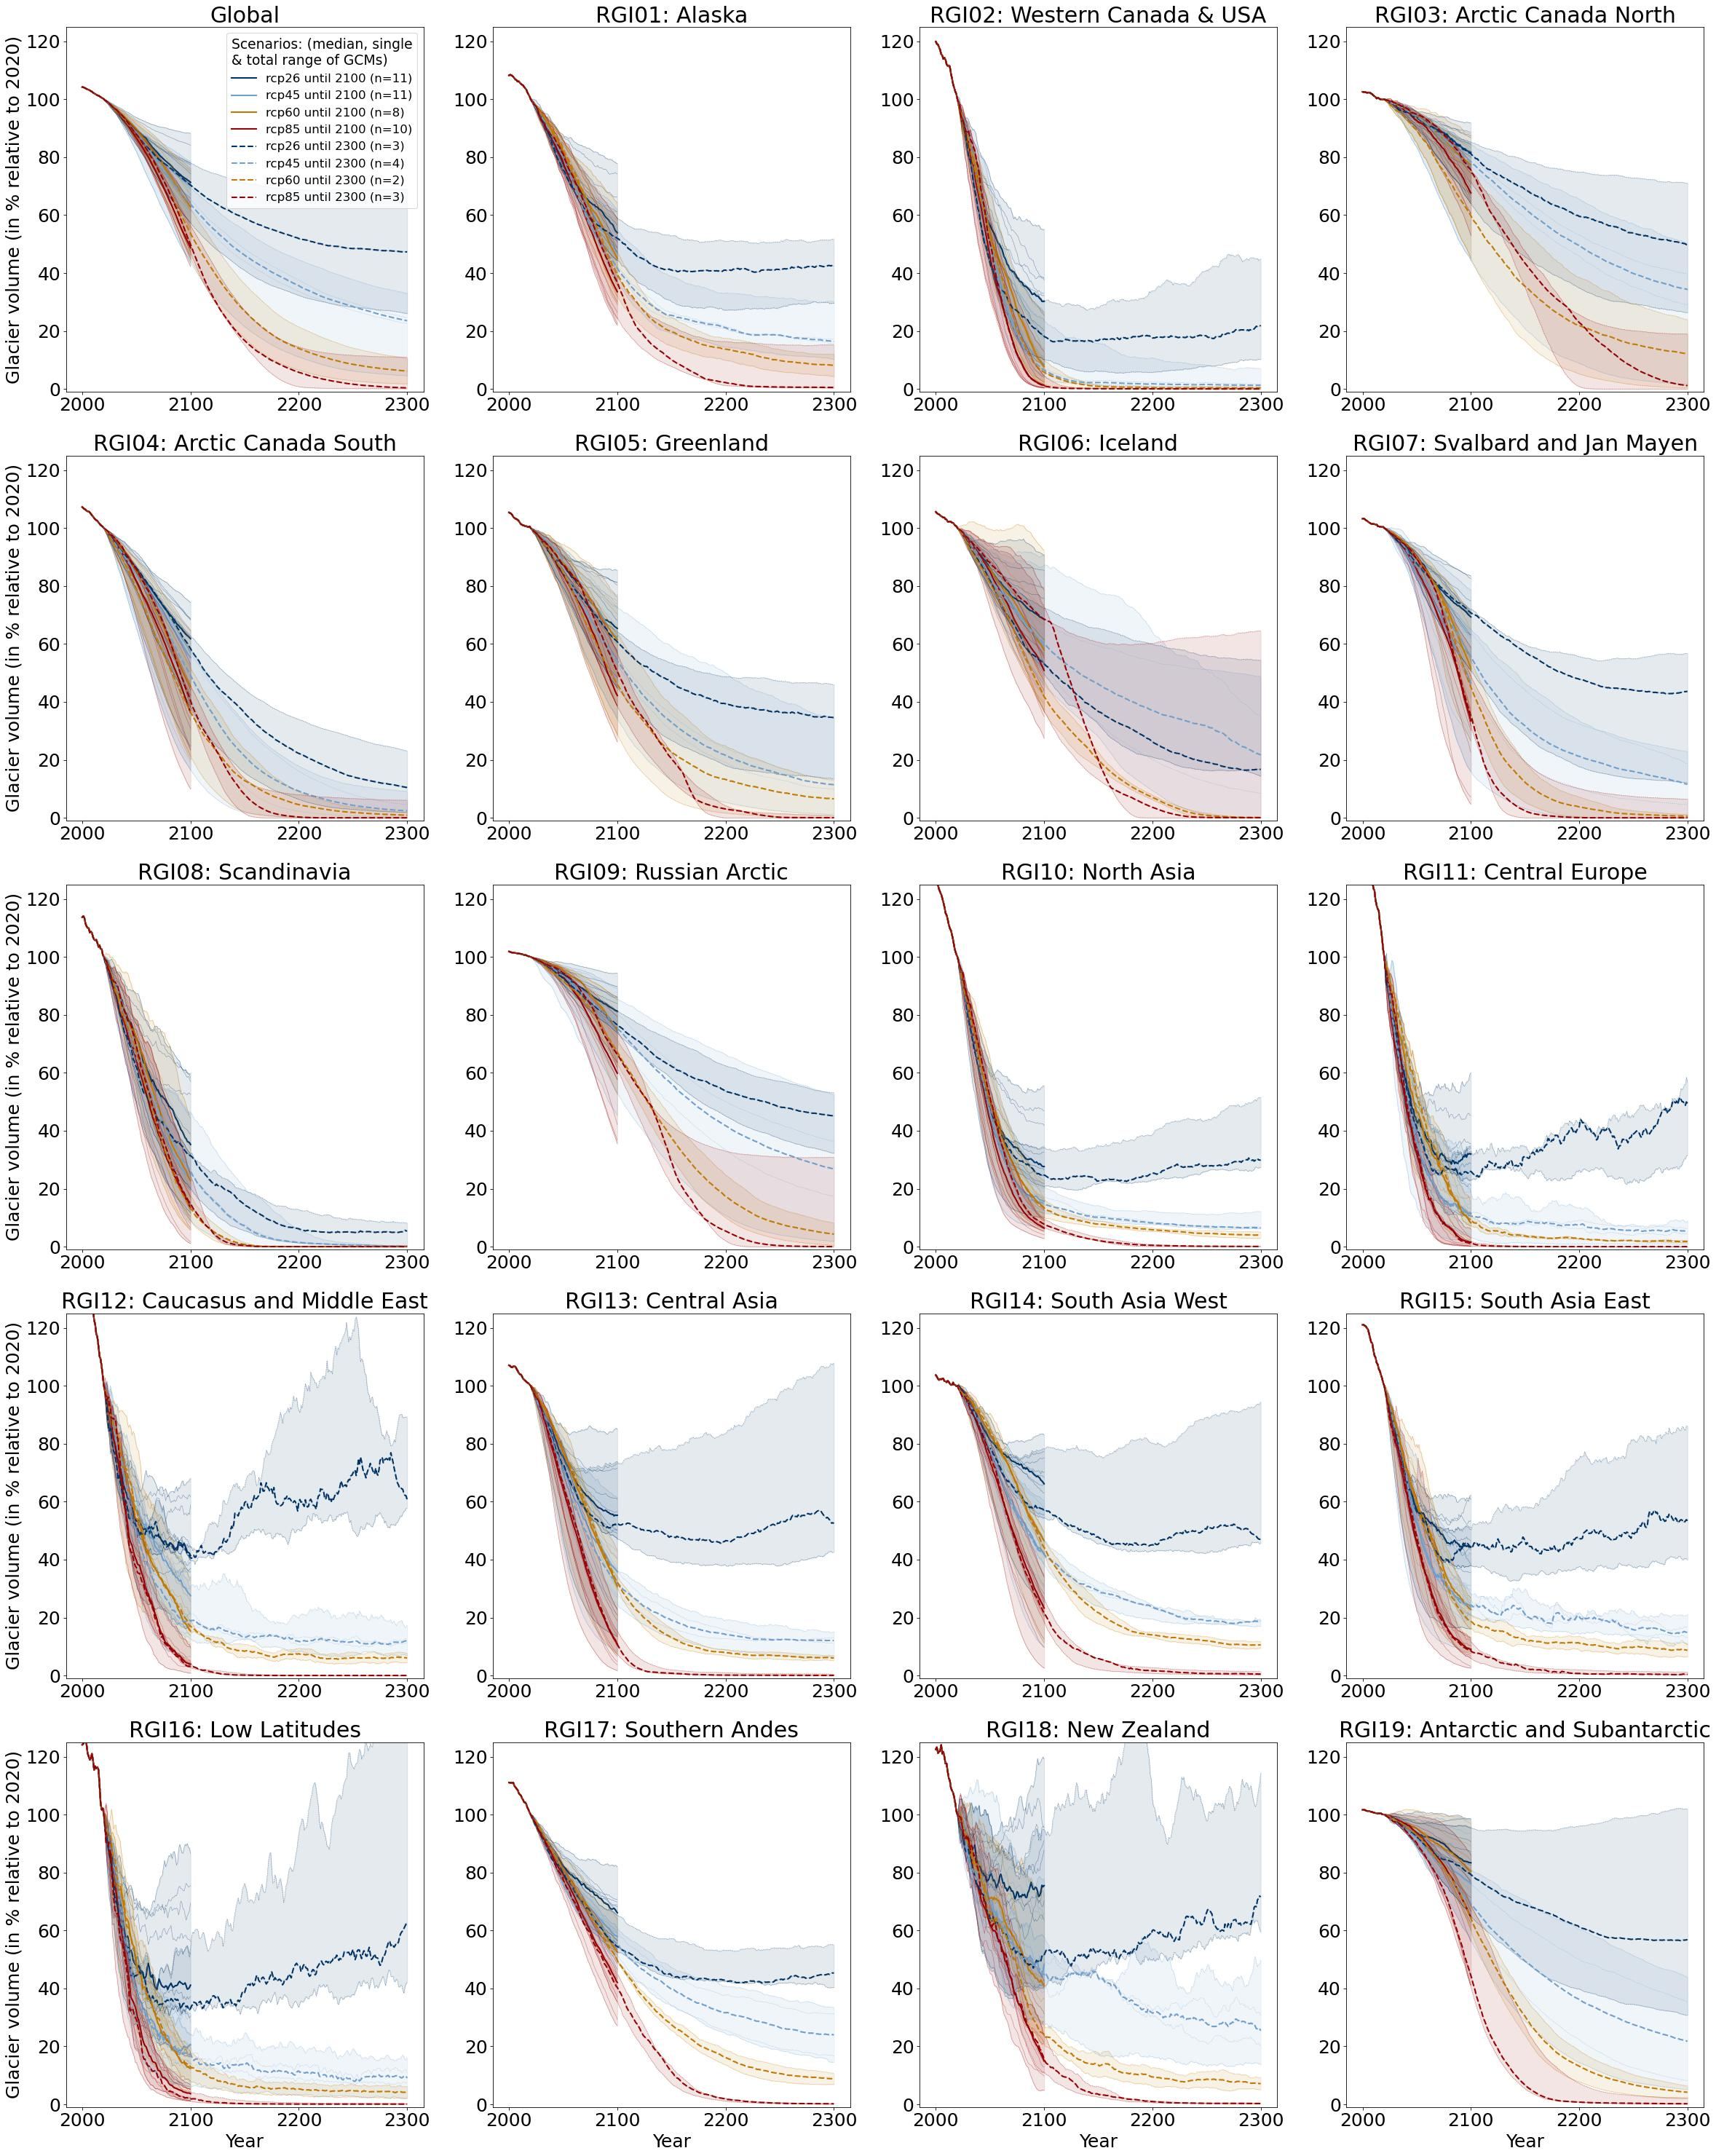

In [11]:
df_meta = pd.read_csv(f'{path}/common_running_2100_2300/metadata.csv')
end_year= 2100
ls_d = {2100:'-', 2300:'--'}
cmip = 'CMIP5'
plt.rc('font', size=24)
plt.figure(figsize=(32,40)) #harey=True, sharex=True)

for j,r in enumerate(['Global', 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]):
    plt.subplot(5,4,j+1)
    ax = plt.gca()

    if r == 'Global':
        rgi_reg = r
        rgi_reg_l = 'global'
        ax.set_title('Global')
    else:
        rgi_reg = f'{r:02}'
        rgi_reg_l = f'RGI{rgi_reg}'
        ax.set_title(f'{rgi_reg_l}: {d_reg_num_name[rgi_reg]}')
        
    for end_year in [2100,2300]:
        ls = ls_d[end_year]
        # let's only plot those scenarios that exist only until 2300
        scenario_list = list(df_meta.loc[(df_meta.cmip==cmip) & 
                             ((df_meta.end_year==2300)|(df_meta.end_year==2301))].scenario.unique())
        scenario_list.sort()
        for scenario in scenario_list:
            idir = path + 'common_running_2100_2300/' + f'volume/{cmip}/{end_year}/{rgi_reg_l}/'

            df = pd.read_csv(idir + f'{scenario}.csv', index_col=0)
            df_rel = 100*df/df.loc[2020]

            ax.plot(df.index, df_rel.median(axis=1), lw=2, color=colors_scenario[scenario],
                    label = f'{scenario} until {end_year} (n={len(df_rel.columns)})', ls= ls_d[end_year])
            ax.plot(df.index, df_rel, lw=0.5, alpha = 0.5, color=colors_scenario[scenario],
                   ls= ls_d[end_year]);
            ax.fill_between(df.index, df_rel.min(axis=1), df_rel.max(axis=1), alpha=0.1, color=colors_scenario[scenario])
    if j in [0,4,8,12,16]:
        ax.set_ylabel('Glacier volume (in % relative to 2020)')
    if j>=16:
        ax.set_xlabel('Year')
    if j == 0:
        ax.legend(title='Scenarios: (median, single\n& total range of GCMs)', ncol=1, fontsize=16, title_fontsize=18, loc = 'upper right');
    ax.set_ylim([-1,125])
plt.tight_layout()
plt.savefig('regional_glacier_volume_until2300_common_running_2100_2300_cmip5.png')

### Comparison between versions (currently OGGM v1.6.1 & v1.6.3)

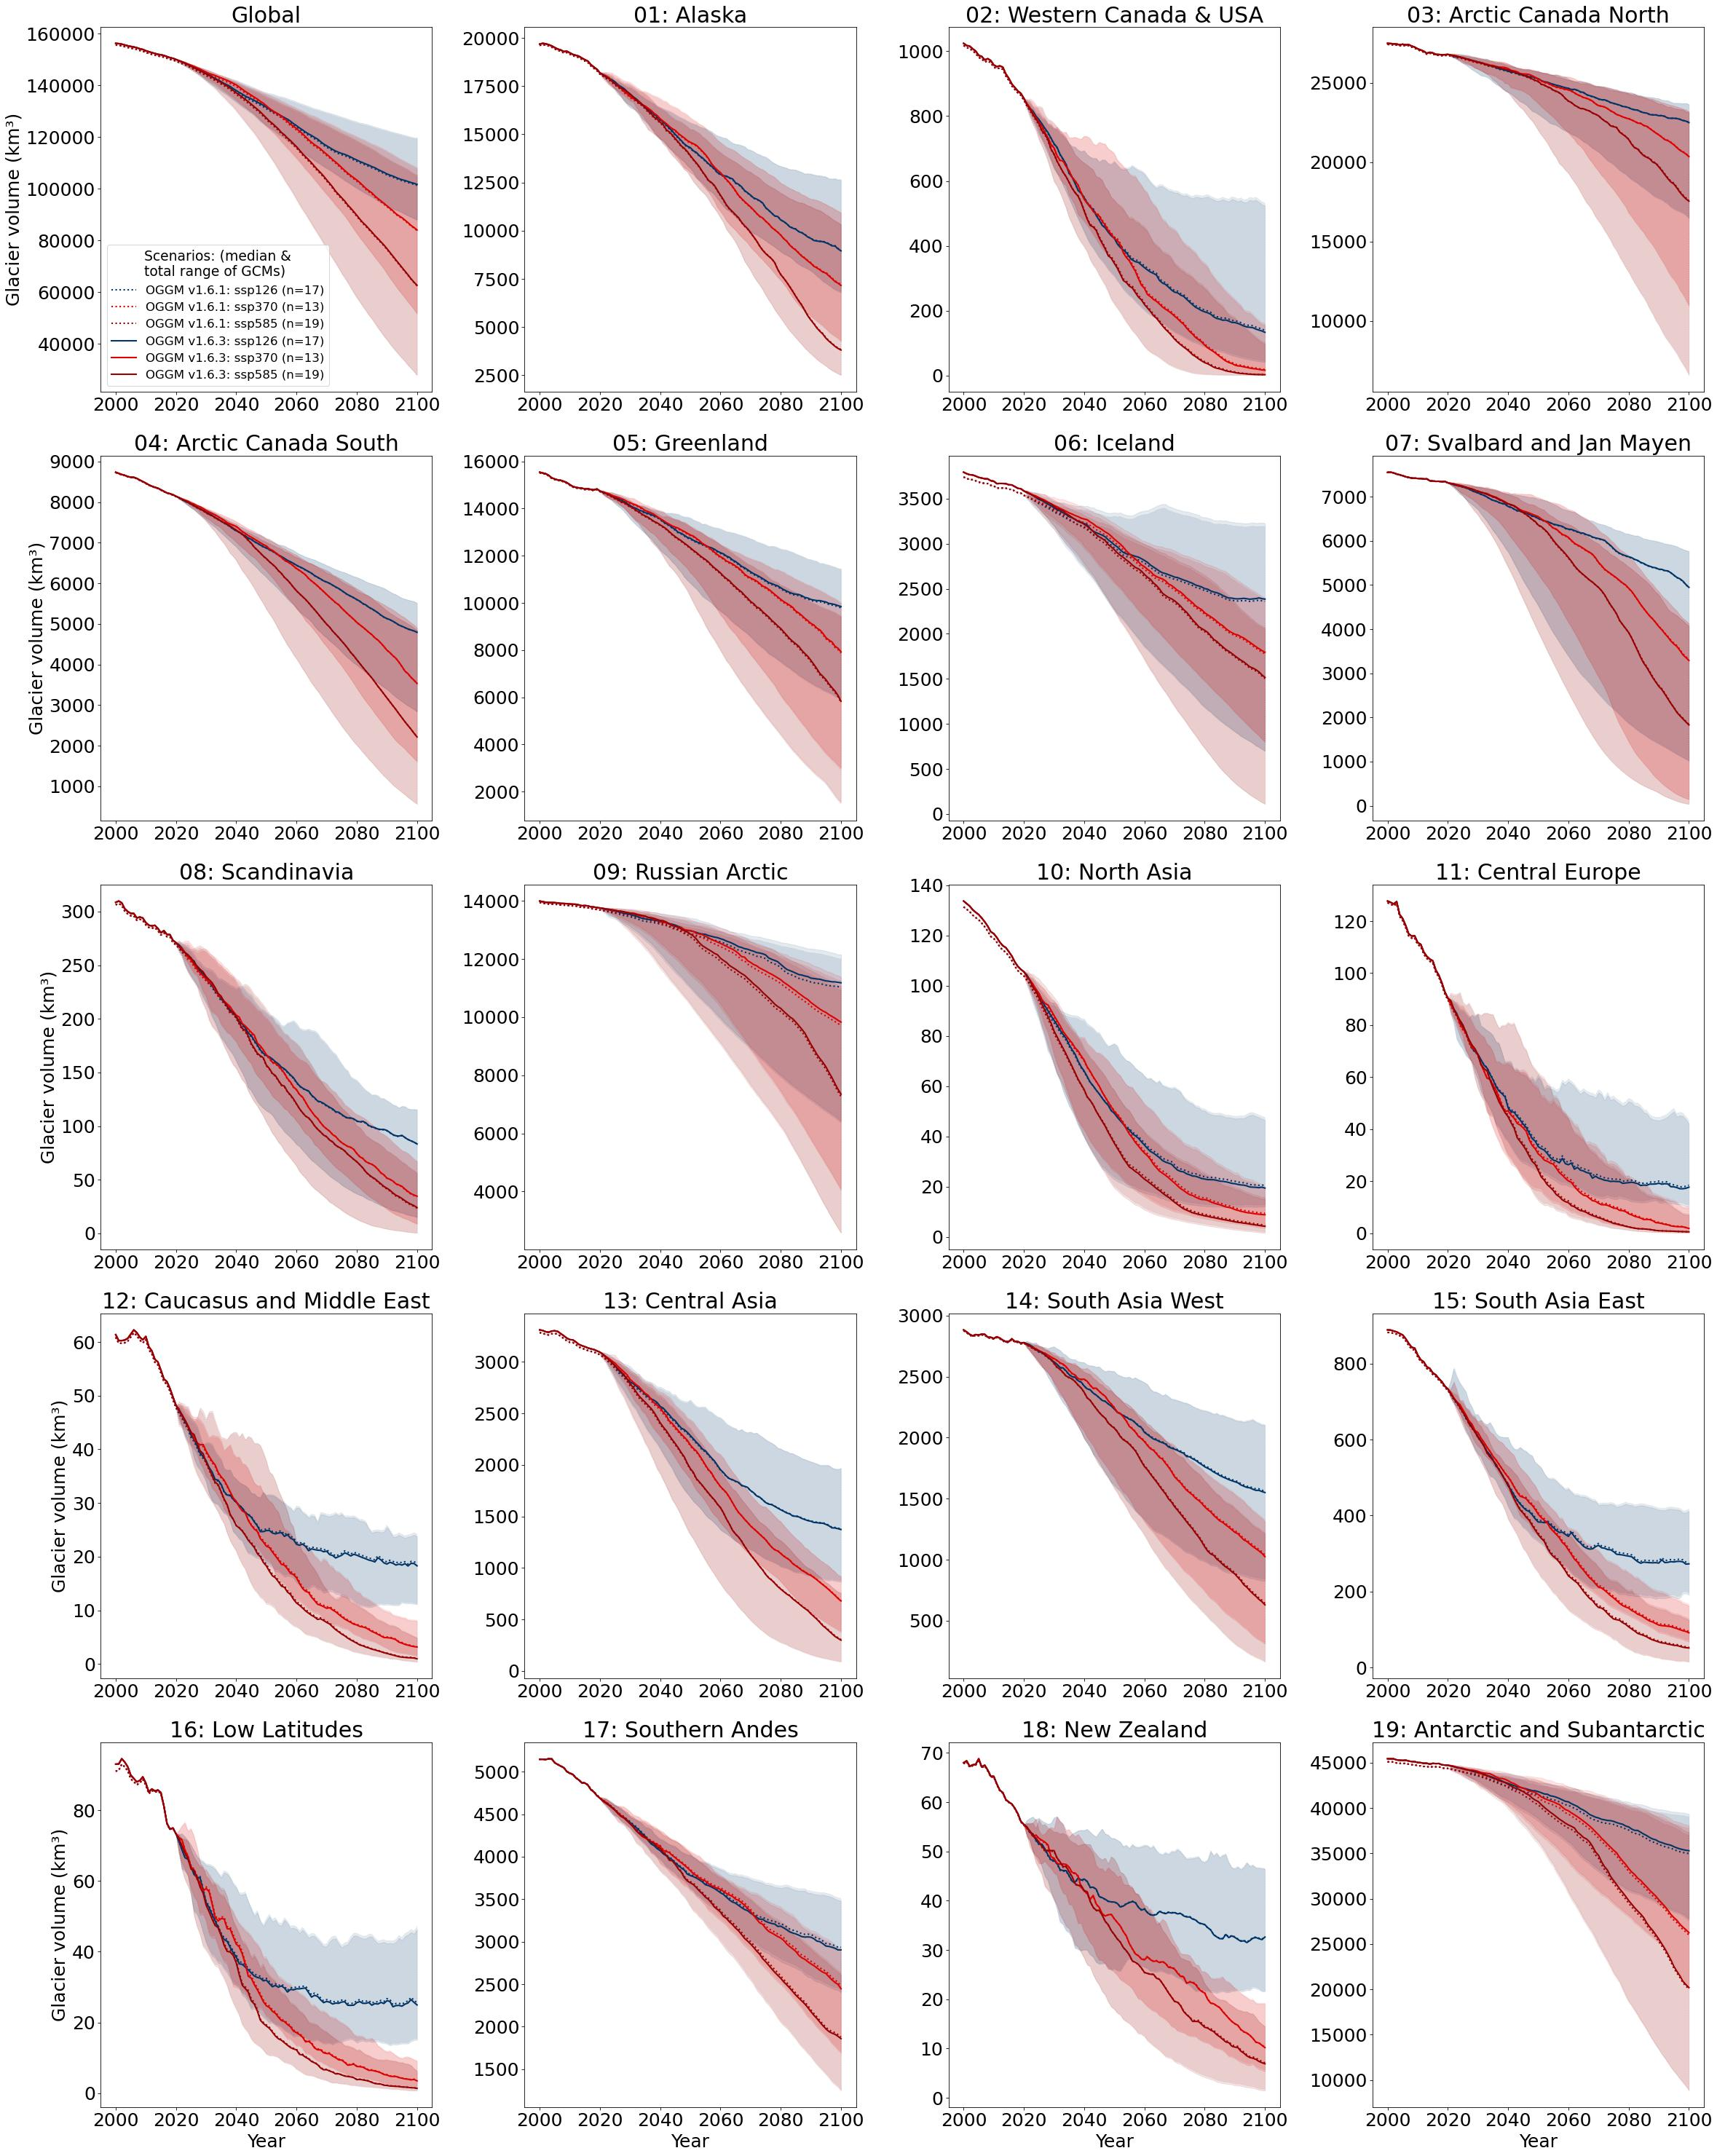

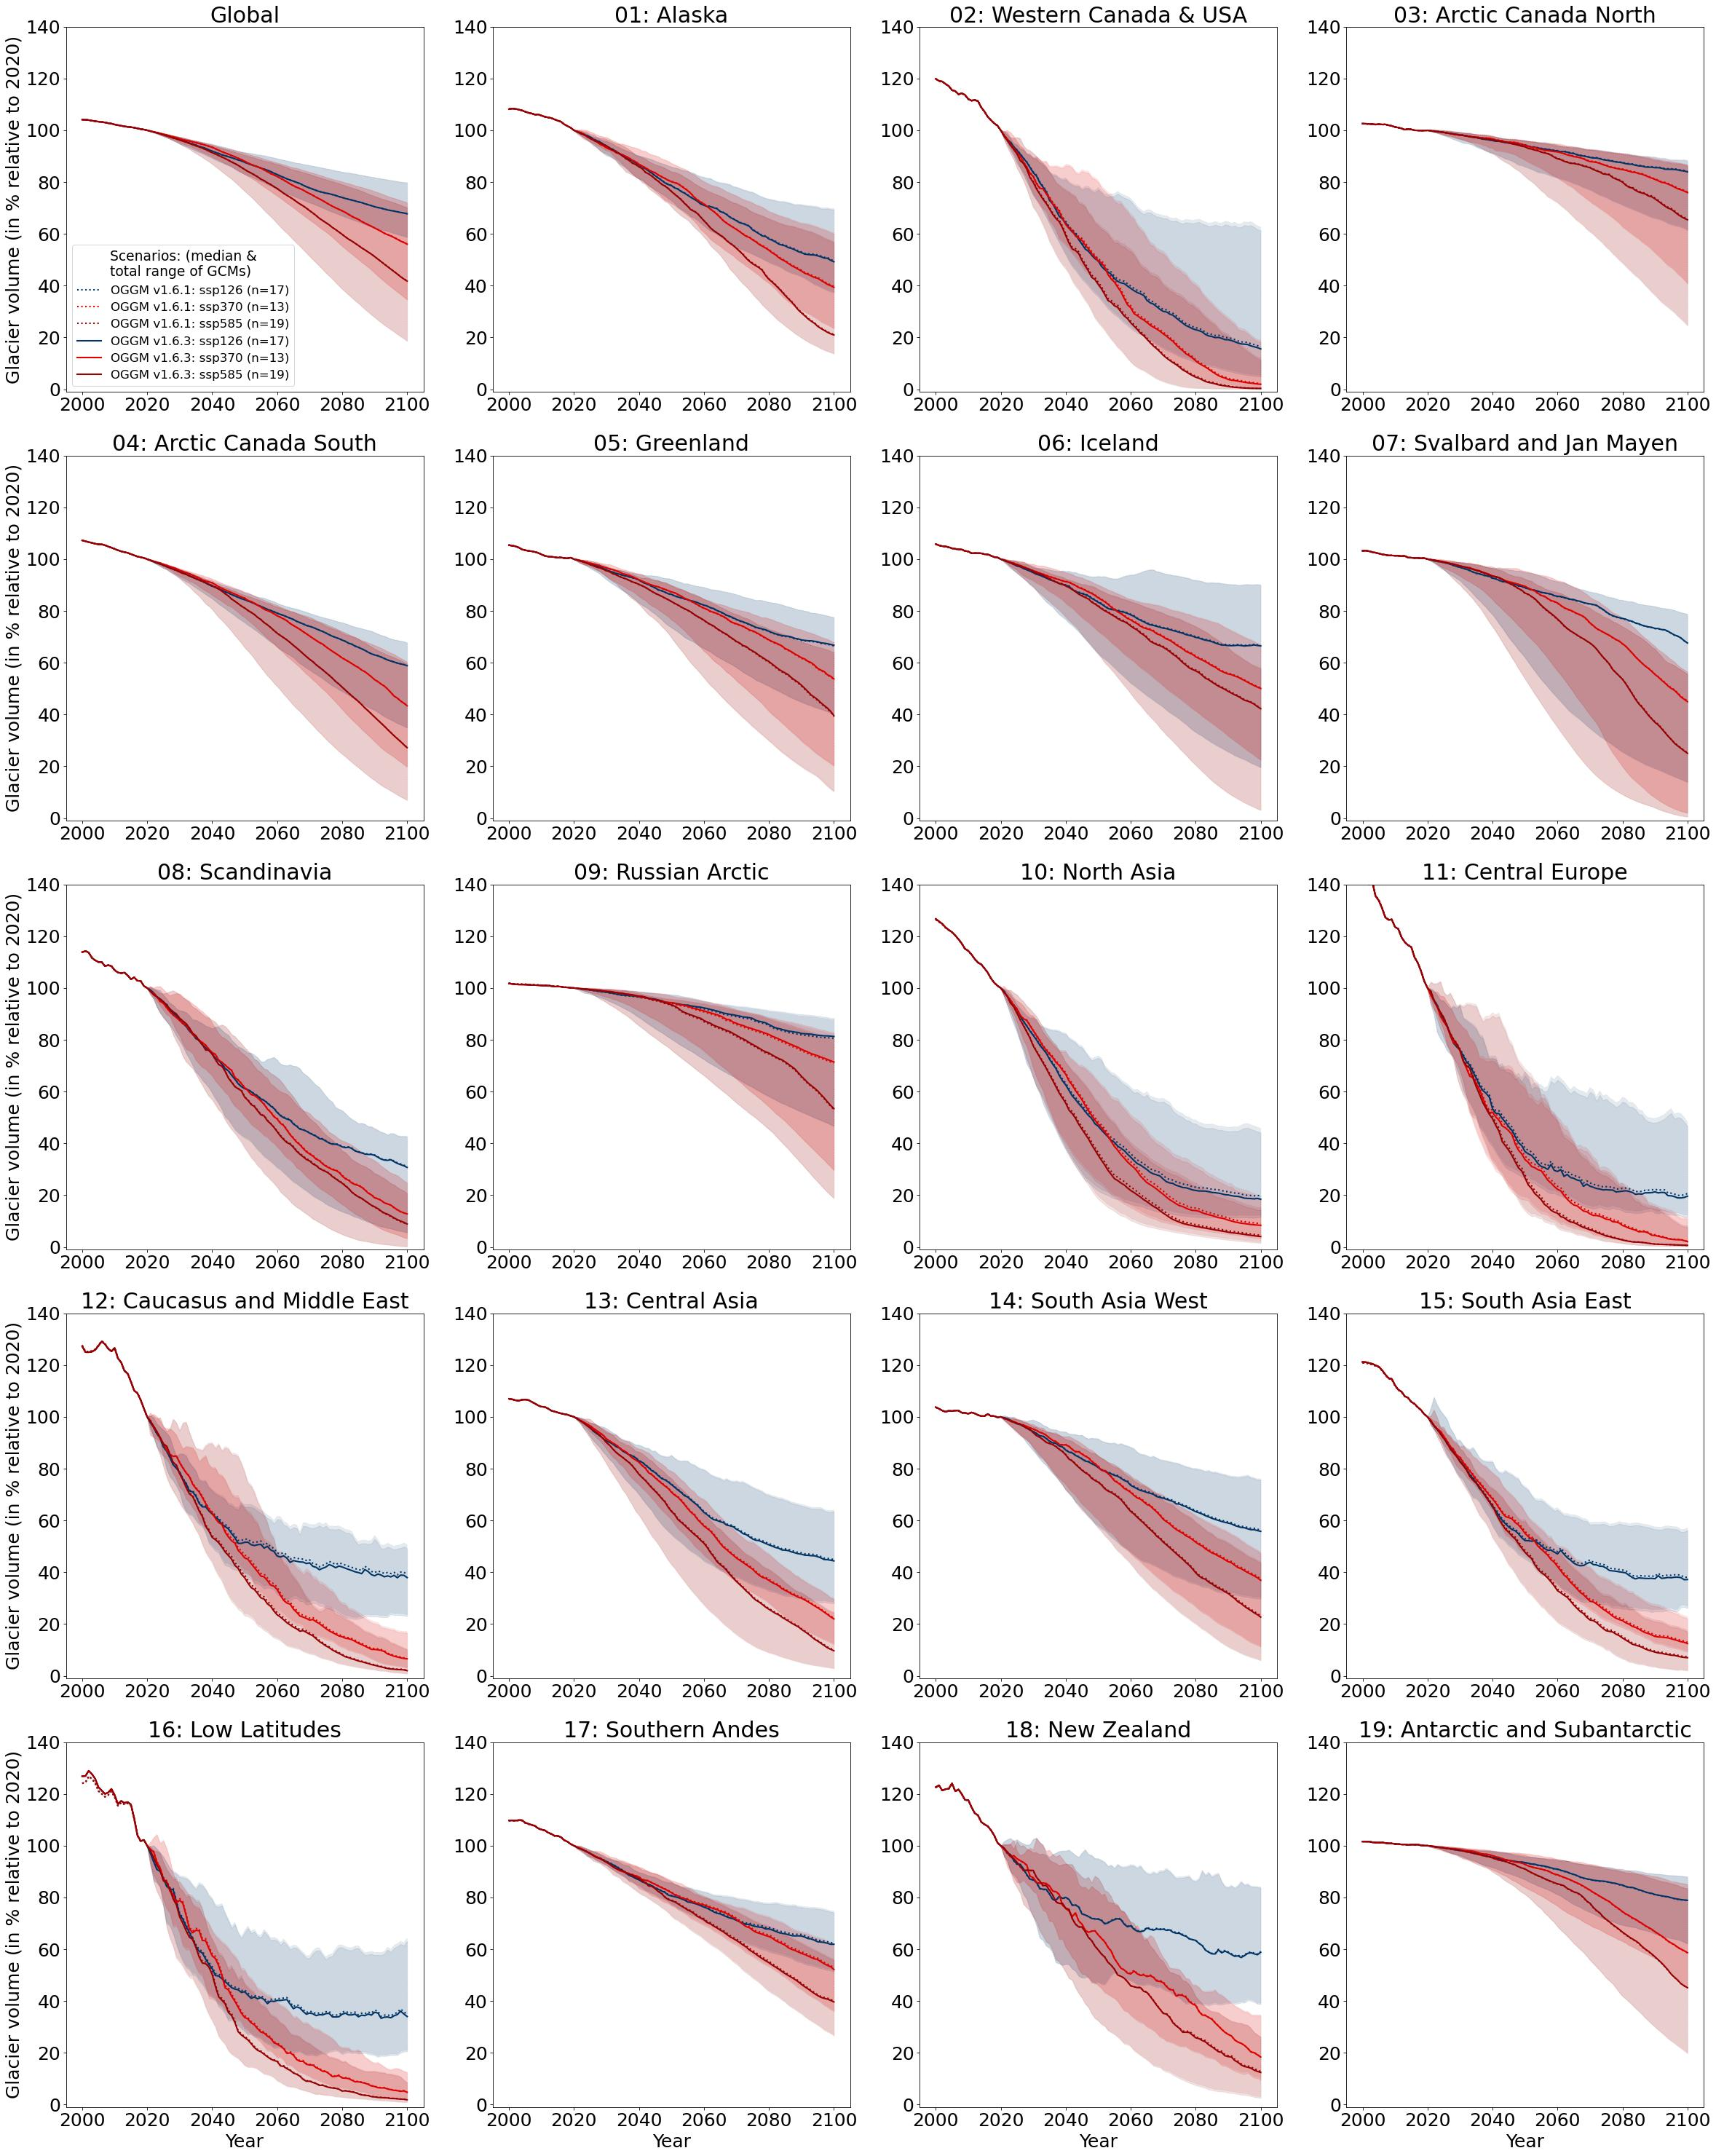

In [12]:
path_161 = '/home/www/oggm/oggm-standard-projections/oggm-standard-projections-csv-files/1.6.1/'

end_year= 2100
ls_d = {'oggm_163':'-', 'oggm_161':':'}
cmip = 'CMIP6'
plt.rc('font', size=24)
comp_dict = {}
for opt in ['absolute', 'relative']:
    plt.figure(figsize=(32,40))    
    for j,r in enumerate(['Global', 1,  2,  3,  4,  5,  6,  7,  8,  9,
                          10, 11, 12, 13, 14, 15, 16, 17, 18, 19]):
        plt.subplot(5,4,j+1)
        ax = plt.gca()
    
        if r == 'Global':
            rgi_reg = r
            rgi_reg_l = 'global'
            ax.set_title('Global')
        else:
            rgi_reg = f'{r:02}'
            rgi_reg_l = f'RGI{rgi_reg}'
            ax.set_title(f'{rgi_reg_l[3:]}: {d_reg_num_name[rgi_reg]}')
        
        for version in ['oggm_161','oggm_163']:
            if version == 'oggm_161':
                _path = path
                label = 'OGGM v1.6.1'
            else:
                _path = path_161
                label = 'OGGM v1.6.3'
            df_meta = pd.read_csv(f'{_path}/common_running_2100/metadata.csv')
    
            # let's only plot those until 2100 
            scenario_list = list(df_meta.loc[(df_meta.cmip==cmip) & 
                                 ((df_meta.end_year==2100)|(df_meta.end_year==2101))].scenario.unique())
            scenario_list.sort()
            for scenario in ['ssp126', 'ssp370','ssp585']:
                idir = _path + 'common_running_2100/' + f'volume/{cmip}/{end_year}/{rgi_reg_l}/'
    
                df = pd.read_csv(idir + f'{scenario}.csv', index_col=0)
                if opt == 'absolute':
                    _df = df/1e9
                else:
                    _df = 100*df/df.loc[2020]
    
                ax.plot(_df.index, _df.median(axis=1), lw=2, color=colors_scenario[scenario],
                        label = f'{label}: {scenario} (n={len(_df.columns)})', ls= ls_d[version])
                ax.fill_between(_df.index, _df.min(axis=1), _df.max(axis=1),
                                alpha=0.1, color=colors_scenario[scenario], ls= ls_d[version])
                comp_dict[f'{opt}_{rgi_reg}_{version}_{scenario}'] = _df
        if j in [0,4,8,12,16]:
            if opt == 'relative':
                ax.set_ylabel('Glacier volume (in % relative to 2020)')
            else:
                ax.set_ylabel('Glacier volume (km³)')                
        if j>=16:
            ax.set_xlabel('Year')
        if j == 0:
            ax.legend(title='Scenarios: (median &\ntotal range of GCMs)',
                      ncol=1, fontsize=16, title_fontsize=18, loc = 'lower left');
        if opt == 'relative':
            ax.set_ylim([-1,140])
    plt.tight_layout()
    plt.savefig(f'regional_glacier_volume_until2100_{opt}_oggm_version_comparison_cmip6.png')

Check how large the differences are:

In [13]:
opt = 'relative'
for j,r in enumerate(['Global', 1,  2,  3,  4,  5,  6,  7,  8,  9,
                      10, 11, 12, 13, 14, 15, 16, 17, 18, 19]):

    if r == 'Global':
        rgi_reg = r
    else:
        rgi_reg = f'{r:02}'
    for scenario in ['ssp126', 'ssp370','ssp585']:
        vol_163 = comp_dict[f'{opt}_{rgi_reg}_oggm_163_{scenario}']
        vol_161 = comp_dict[f'{opt}_{rgi_reg}_oggm_161_{scenario}']
        abs_diff = (np.abs(vol_163-vol_161))
        if r == 'Global':
            # print it anyways
            print(rgi_reg, scenario, ':', np.round(abs_diff.max().max(),2), '%', 'in year', abs_diff.max(axis=1).idxmax())
        if abs_diff.max().max() > 1:
            print(rgi_reg, scenario, ':', np.round(abs_diff.max().max(),2), '%', 'in year', abs_diff.max(axis=1).idxmax())
        if abs_diff.loc[2100].max() >1:
            print(rgi_reg, scenario, 'in year 2100: ', np.round(abs_diff.loc[2100].max(),2), '%')
        if abs_diff.loc[2000].max() >1:
            print(rgi_reg, scenario, 'in year 2000: ', np.round(abs_diff.loc[2000].max(),2), '%')

Global ssp126 : 0.06 % in year 2100.0
Global ssp370 : 0.11 % in year 2100.0
Global ssp585 : 0.18 % in year 2100.0
02 ssp126 : 1.43 % in year 2100.0
02 ssp126 in year 2100:  1.43 %
02 ssp370 : 1.08 % in year 2070.0
02 ssp585 : 1.02 % in year 2060.0
10 ssp126 : 1.73 % in year 2100.0
10 ssp126 in year 2100:  1.73 %
10 ssp370 : 1.44 % in year 2077.0
10 ssp370 in year 2100:  1.14 %
10 ssp585 : 1.36 % in year 2068.0
11 ssp126 : 1.82 % in year 2095.0
11 ssp126 in year 2100:  1.72 %
11 ssp370 : 1.58 % in year 2055.0
11 ssp585 : 1.54 % in year 2052.0
12 ssp126 : 1.42 % in year 2099.0
12 ssp126 in year 2100:  1.41 %
12 ssp370 : 1.2 % in year 2061.0
12 ssp585 : 1.09 % in year 2054.0
15 ssp126 : 1.06 % in year 2098.0
15 ssp126 in year 2100:  1.06 %
16 ssp126 : 2.76 % in year 2000.0
16 ssp126 in year 2100:  1.11 %
16 ssp126 in year 2000:  2.76 %
16 ssp370 : 2.76 % in year 2000.0
16 ssp370 in year 2000:  2.76 %
16 ssp585 : 2.76 % in year 2000.0
16 ssp585 in year 2000:  2.76 %


- In 2000: the initial volume for OGGM v1.6.3 is approximately 3% larger than v1.6.1 in region 16. In all other regions, starting differences are negligible (<1%).
- Through 2100, the versions remain highly consistent, with differences staying under 0.2% globally and under 1% regionally. The only exceptions are regions 02, 10, 11, 12, 15, and 16, where deviations reach a maximum of 1.0% to 2.0%.

**What next?**
- if you are interested in a comparison to Rounce et al. (2023), you can check out [this jupyter notebook](https://nbviewer.org/urls/cluster.klima.uni-bremen.de/~oggm/oggm-standard-projections/oggm-standard-projections-csv-files/notebooks/compare_oggm_1.6.1_to_rounce_et_al_2023.ipynb?flush_cache=true) where we compared explicitly the common running glaciers of OGGM v1.6.1 to Rounce et al. (2023)
- if you want to compare the OGGM standard projections v1.6.3 to other options using equally OGGM v1.6.3 (ERA5, regional spinup, RGI70; just for a single GCM), check out [this OGGM cluster notebook](https://nbviewer.org/urls/cluster.klima.uni-bremen.de/~oggm/oggm-standard-projections/analysis_notebooks/1.6.3_2025_6_gdirs_proj_comparisons/3_volume_projection_differences.ipynb)
- some example analysis of the raw oggm per-glacier files (together with for example runoff analysis) is in [this notebook](https://nbviewer.org/urls/cluster.klima.uni-bremen.de/~oggm/oggm-standard-projections/analysis_notebooks/workflow_to_analyse_per_glacier_projection_files.ipynb?flush_cache=true)